In [56]:
import pandas as pd
import matplotlib.pyplot  as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree

# Load data
df = pd.read_csv(r"C:\Users\luisa\Downloads\DNDdf_with_GDP.csv")


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


df_encoded = pd.get_dummies(
    df,
    columns=["Disease Category", "Age Group", "Gender"],
    drop_first=True
)

df_sample = df_encoded.sample(1_000_000, random_state=42)

X = df_sample.drop(columns=["Mortality Rate (%)"])
y = df_sample["Mortality Rate (%)"]

X = pd.get_dummies(X, drop_first=True)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [87]:

rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

In [88]:
df_sample.corr(numeric_only=True)["Mortality Rate (%)"].sort_values()

Population Affected               -0.001831
Disease Category_Parasitic        -0.001741
Average Treatment Cost (USD)      -0.001554
Per Capita Income (USD)           -0.001503
DALYs                             -0.001095
Age Group_61+                     -0.000771
Disease Category_Genetic          -0.000740
Disease Category_Chronic          -0.000736
Disease Category_Bacterial        -0.000487
GDP                               -0.000433
Education Index                   -0.000110
Disease Category_Respiratory      -0.000053
Healthcare Access (%)              0.000077
Urbanization Rate (%)              0.000169
Improvement in 5 Years (%)         0.000197
Age Group_19-35                    0.000219
Incidence Rate (%)                 0.000323
Disease Category_Infectious        0.000381
Year                               0.000448
Disease Category_Viral             0.000520
Age Group_36-60                    0.000568
Gender_Male                        0.000729
Recovery Rate (%)               

In [89]:
df_sample["Mortality Rate (%)"].describe()

count    1000000.000000
mean           5.049919
std            2.859427
min            0.100000
25%            2.580000
50%            5.050000
75%            7.530000
max           10.000000
Name: Mortality Rate (%), dtype: float64

In [90]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [91]:
y_pred = rf.predict(X_test)

In [92]:
print("Random Forest R²:", r2_score(y_test, y_pred))

Random Forest R²: -3.6274499508826e-05


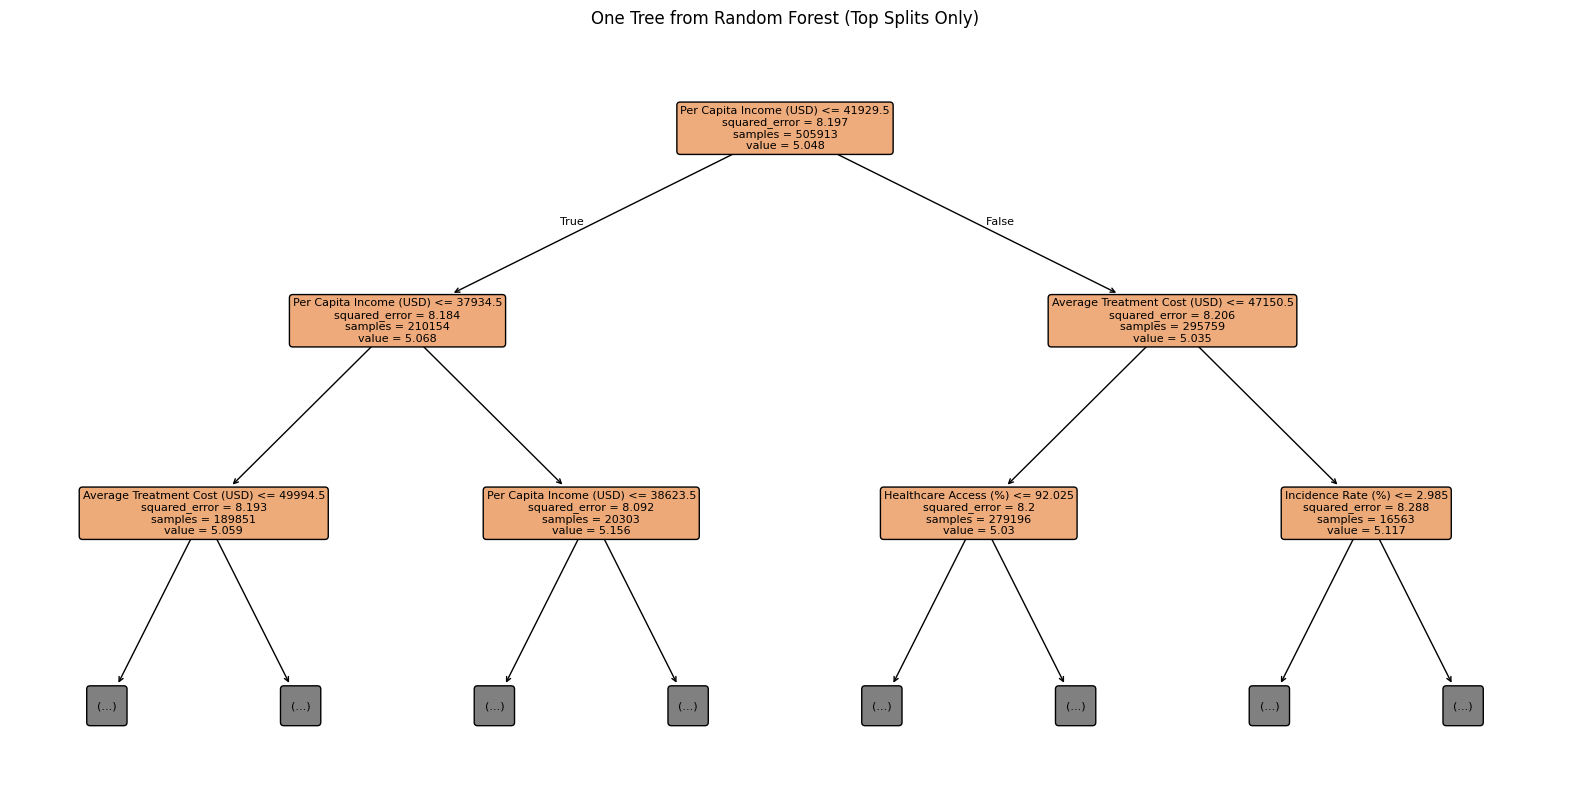

In [94]:


single_tree = rf.estimators_[1]

plt.figure(figsize=(20,10))
plot_tree(
    single_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=2,  
    fontsize=8
)
plt.title("One Tree from Random Forest (Top Splits Only)")
plt.show()

In [74]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

-1.3138152903380274e-06

In [75]:
print(len(X), len(y))
print(X.index.equals(y.index))

500000 500000
True
